In [1]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Basic understanding

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


total_bill have mean > median
so checking skewness

<Axes: xlabel='total_bill', ylabel='Count'>

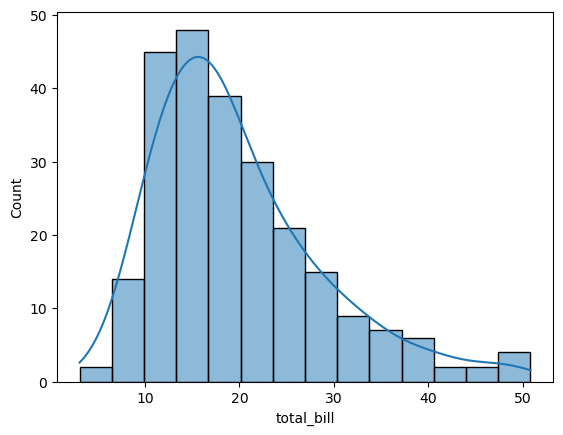

In [3]:
sns.histplot(df['total_bill'], kde = True)

checking outliers

<Axes: ylabel='total_bill'>

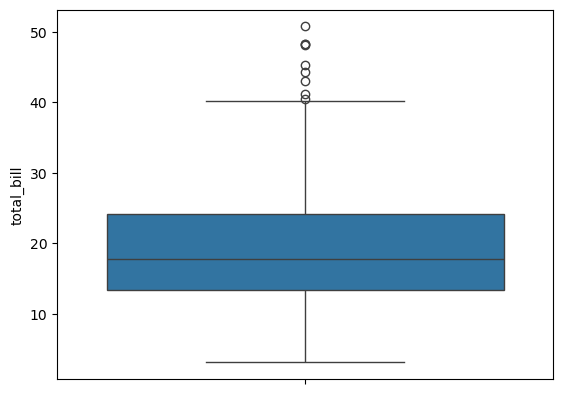

In [4]:
sns.boxplot(y = df['total_bill'])

encording sex column

In [8]:
df = pd.get_dummies(df, columns = ['sex'], drop_first = True)

In [9]:
df

,total_bill,tip,smoker,day,time,size,sex_Female
0,16.99,1.01,No,Sun,Dinner,2,True
1,10.34,1.66,No,Sun,Dinner,3,False
2,21.01,3.50,No,Sun,Dinner,3,False
3,23.68,3.31,No,Sun,Dinner,2,False
4,24.59,3.61,No,Sun,Dinner,4,True
...,...,...,...,...,...,...,...
239,29.03,5.92,No,Sat,Dinner,3,False
240,27.18,2.00,Yes,Sat,Dinner,2,True
241,22.67,2.00,Yes,Sat,Dinner,2,False
242,17.82,1.75,No,Sat,Dinner,2,False


correlation matrix and heatmap

In [10]:
cor = df.corr(numeric_only = True)
cor

,total_bill,tip,size,sex_Female
total_bill,1.000000,0.675734,0.598315,-0.144877
tip,0.675734,1.000000,0.489299,-0.088862
size,0.598315,0.489299,1.000000,-0.086195
sex_Female,-0.144877,-0.088862,-0.086195,1.000000


<Axes: >

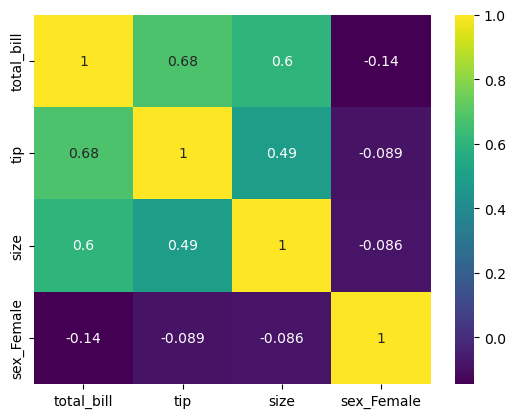

In [11]:
sns.heatmap(cor, cmap = 'viridis', annot = True)

covariance

In [14]:
cov = df.cov(numeric_only = True)
cov

,total_bill,tip,size,sex_Female
total_bill,79.252939,8.323502,5.065983,-0.619041
tip,8.323502,1.914455,0.643906,-0.059013
size,5.065983,0.643906,0.904591,-0.039348
sex_Female,-0.619041,-0.059013,-0.039348,0.230368


<Axes: >

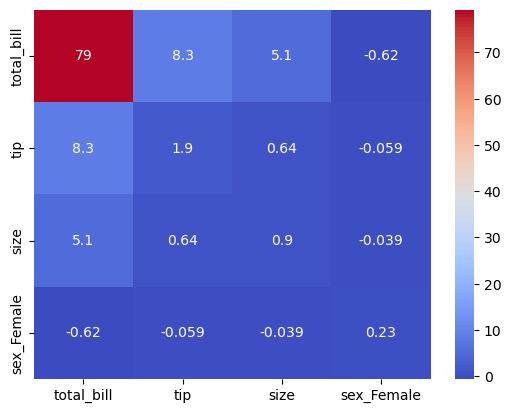

In [15]:
sns.heatmap(cov, cmap = 'coolwarm', annot = True)

Doing pair plot for understanding the relations in them

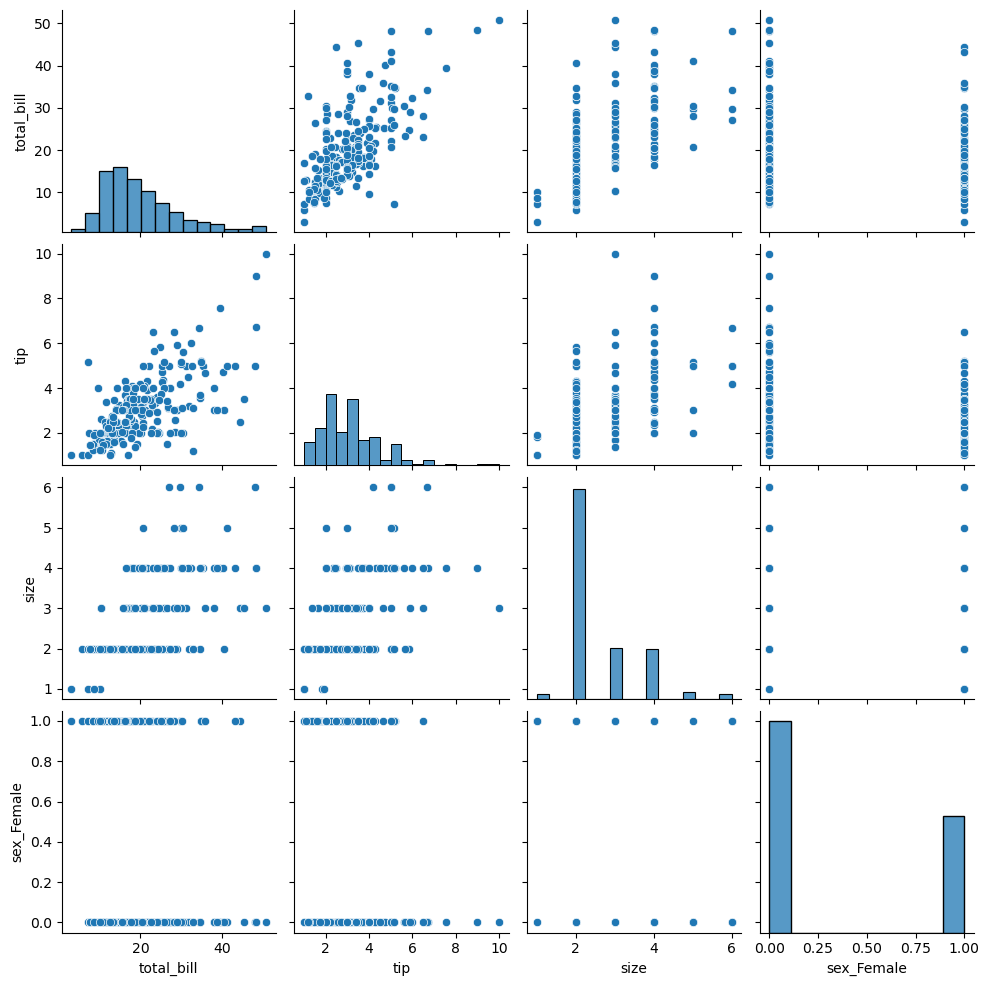

In [12]:
sns.pairplot(df)